Fitting one point cloud to another: gradient flows
==================================================

**When to use:** you want to move or generate points so that they match a target shape or distribution
(registration, shape fitting, generative models), with the loss as the objective.

**What you will see:** 30,000 particles following the gradient of the loss to a target shape of 30,000 points,
with and without debiasing, coloured so that tearing and folding stay visible; the average time per step and
the peak memory of each flow; and an animation of the flow. GeomLoss's gallery shows the same flow for other losses:
https://www.kernel-operations.io/geomloss/_auto_examples/comparisons/plot_gradient_flows_2D.html

Source: [plot_gradient_flow_2d.py](plot_gradient_flow_2d.py) · [Gallery](../README.md)

Reference figures and quoted results come from previous script runs. They are reading aids, not outputs from an execution of this notebook.

Install `pip install --upgrade 'flash-sinkhorn[notebooks]'`, clone this repository for the example files, and start `jupyter lab` from the checkout. Select its Python environment, then run the cells in order on an NVIDIA CUDA GPU. The setup cell finds the checkout from the repository root or this notebook's folder. The solver comes from the installed package. Running all cells prints fresh results and displays new figures; it also replaces the source's saved images. The scale examples retain the script's full problem sizes.

In [ ]:
# Find this checkout when Jupyter starts at its root or in a notebook folder.
import os
import sys
from pathlib import Path

for _candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (_candidate / 'examples/getting_started/plot_gradient_flow_2d.py').is_file() and (_candidate / "torch-ext/flash_sinkhorn").is_dir():
        _notebook_root = _candidate
        break
else:
    raise RuntimeError("Start Jupyter inside the flash-sinkhorn repository checkout.")

os.chdir(_notebook_root)
# Locate shared example helpers; import the solver from the installed package.
for _path in reversed([_notebook_root / "examples", _notebook_root]):
    if str(_path) in sys.path:
        sys.path.remove(str(_path))
    sys.path.insert(0, str(_path))
__file__ = str(_notebook_root / 'examples/getting_started/plot_gradient_flow_2d.py')

# Display the saved PNG/GIF files explicitly, including figures closed by the source.
import matplotlib
matplotlib.use("Agg")

Setup
-----

In [ ]:
import math
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from flash_sinkhorn import SamplesLoss

sys.path.append(str(Path(__file__).resolve().parents[1]))  # the gallery's shared helpers
from _plotting import (TARGET, dense_size, figure_frame, images_dir, require_cuda, save, save_gif,  # noqa: E402
                       small_multiples, stripes, to_numpy)

device = require_cuda()
torch.manual_seed(0)


def disk(n, center, radius):
    """n points uniform in a disk."""
    r = radius * torch.rand(n, device=device).sqrt()
    angle = 2 * math.pi * torch.rand(n, device=device)
    return torch.stack([r * angle.cos(), r * angle.sin()], dim=1) + torch.tensor(center, device=device)


def crescent(n, center, radius, bite_center, bite_radius):
    """n points uniform in a disk minus an overlapping smaller disk."""
    points = torch.empty(0, 2, device=device)
    while len(points) < n:
        candidates = disk(4 * n, center, radius)
        outside = (candidates - torch.tensor(bite_center, device=device)).norm(dim=1) > bite_radius
        points = torch.cat([points, candidates[outside]])
    return points[:n]


N = 30_000
x0 = disk(N, (-0.5, 0.0), 0.3)
y = crescent(N, (0.4, 0.0), 0.6, (0.65, 0.0), 0.45)
a = torch.full((N,), 1.0 / N, device=device)
b = torch.full((N,), 1.0 / N, device=device)
colours = stripes(x0)  # each particle keeps the colour of its starting position
y_np = to_numpy(y)
print(dense_size(N, N))

The flow
--------
Explicit Euler steps on the particles: x <- x - lr * grad_x loss / a. With ``half_cost=True``,
-grad_x OT_eps / a_i is close to the displacement from x_i to its barycentric target; the direction of S_eps
also subtracts the displacement of the cloud's transport onto itself. Each step moves the particles lr times
that direction.

In [ ]:
lr, n_steps = 0.05, 100
snapshot_steps = [0, 5, 10, 20, 40, 100]  # t = lr * step = 0, 0.25, 0.5, 1, 2, 5
blur = 0.1


def flow(debias, on_step=None):
    loss = SamplesLoss(blur=blur, half_cost=True, debias=debias, backend="symmetric", autotune=False)
    z = x0.clone()
    snapshots = {0: z.clone()}
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    start = time.perf_counter()
    for step in range(1, n_steps + 1):
        z.requires_grad_(True)
        grad, = torch.autograd.grad(loss(a, z, b, y), z)
        z = (z - lr * grad / a[:, None]).detach()
        if step in snapshot_steps:
            snapshots[step] = z.clone()
        if on_step is not None:
            on_step(step, z)
    torch.cuda.synchronize()
    per_step = (time.perf_counter() - start) / n_steps
    peak = torch.cuda.max_memory_allocated() / 2**30
    if on_step is None:  # with on_step, the time would include drawing the frames
        print(f"debias={debias}: {1e3 * per_step:.1f} ms per step, peak memory {peak:.2f} GiB "
              f"on {torch.cuda.get_device_name()}, final loss {loss(a, z, b, y).item():.2e}")
    return snapshots


def draw(ax, z, title):
    ax.scatter(y_np[:, 0], y_np[:, 1], s=0.3, color=TARGET, alpha=0.3, edgecolors="none", rasterized=True)
    z = to_numpy(z)
    ax.scatter(z[:, 0], z[:, 1], s=0.3, c=colours, edgecolors="none", rasterized=True)
    ax.set_xlim(-1.0, 1.2)
    ax.set_ylim(-0.8, 0.8)
    ax.set_title(title, fontsize=9)

With and without debiasing
--------------------------
Top row: the entropic OT cost OT_eps. Bottom row: the Sinkhorn divergence S_eps. The colours follow each
particle from its starting position. The printed time per step averages the whole flow, including the
compilation of kernels on first use (``autotune=False``, as in the basics example).

In [ ]:
fig, axes = small_multiples(2, len(snapshot_steps), size=2.6, aspect=1.6 / 2.2)  # the panels show 2.2 x 1.6
for row, debias in enumerate([False, True]):
    snapshots = flow(debias)
    for col, step in enumerate(snapshot_steps):
        draw(axes[row, col], snapshots[step], f"{'S_eps' if debias else 'OT_eps'}, t = {lr * step:.2f}")
save(fig, images_dir(__file__), "gradient_flow")

In [ ]:
from IPython.display import Image as _NotebookImage, display as _notebook_display
_notebook_display(_NotebookImage(filename=str(_notebook_root / 'examples/getting_started/images/gradient_flow.png')))
# Release figure managers so repeated runs do not accumulate open figures.
import matplotlib.pyplot as _notebook_plt
_notebook_plt.close("all")

**Reference figure from previous script runs.**

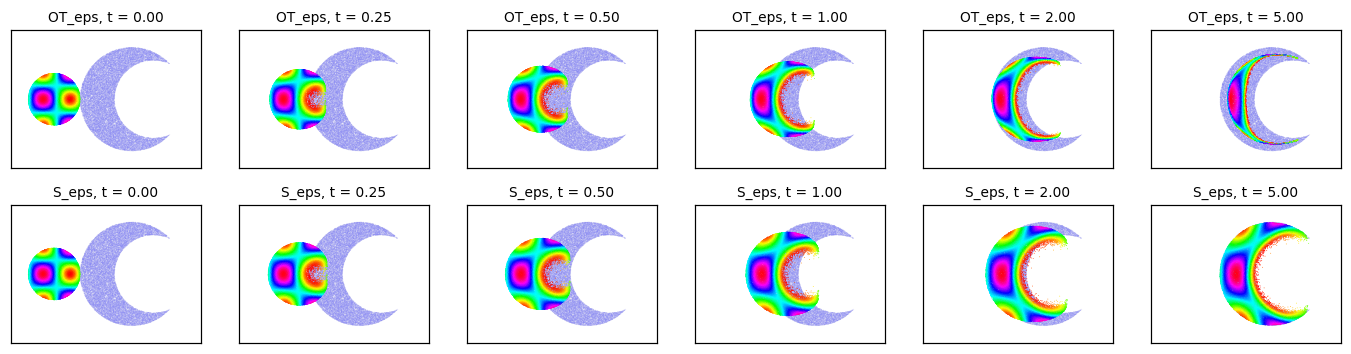

Animation
---------

In [ ]:
frames = []
fig_anim, ax_anim = plt.subplots(figsize=(3.6, 3.6 * 1.6 / 2.2), dpi=80)


def record(step, z):
    if step % 2:
        return
    ax_anim.clear()
    ax_anim.set_aspect("equal")
    ax_anim.set_xticks([])
    ax_anim.set_yticks([])
    draw(ax_anim, z, f"S_eps flow, t = {lr * step:.1f}")
    frames.append(figure_frame(fig_anim))


record(0, x0)
flow(True, on_step=record)
save_gif(frames, images_dir(__file__), "gradient_flow")
plt.show()

In [ ]:
from IPython.display import Image as _NotebookImage, display as _notebook_display
_notebook_display(_NotebookImage(filename=str(_notebook_root / 'examples/getting_started/images/gradient_flow.gif')))
# Release figure managers so repeated runs do not accumulate open figures.
import matplotlib.pyplot as _notebook_plt
_notebook_plt.close("all")

**Reference figure from previous script runs.**

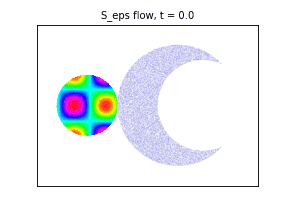